# Public-data multiclass classification: Palmer Penguins

This project transfers the original fraud-cancellation notebook's core methodology to a completely different domain: predicting penguin species from field measurements. It retains pandas/NumPy, a scikit-learn `ColumnTransformer` and `Pipeline`, imputation, scaling, one-hot encoding, multiclass XGBoost probabilities, ROC AUC, confusion tables, artifact persistence, and SHAP explanations.

## Why this dataset

The curated Palmer Penguins data has 344 observations, three target species, numeric and categorical predictors, genuine missing values, and observations from 2007–2009. That last field enables a meaningful out-of-time (OOT) evaluation: develop with 2007–2008 and score 2009 without training on it. The data is CC0 and small enough to study interactively.

Source and documentation: https://github.com/allisonhorst/palmerpenguins

## Other strong next studies

1. **UCI Steel Plates Faults** — 1,941 rows, 27 predictors, seven fault classes. Closest operational analogue to risk/fault classification; good next step for imbalance, per-class AUC, and reason codes.
2. **UCI Dry Bean** — 13,611 rows, 16 image-derived numeric features, seven varieties. Best for deeper multiclass tuning and stable SHAP comparisons, but it does not naturally exercise categorical preprocessing or OOT validation.
3. **Forest CoverType** — 581,012 rows and seven classes, available through `sklearn.datasets.fetch_covtype`. Best for scale, sparse indicators, runtime/memory profiling, and XGBoost tuning; less convenient for a first clean study.

Palmer Penguins is selected because it exercises the widest range of the familiar tools in a compact, inspectable notebook. Treat this as a learning workflow, not a biological identification system.

## Study design and leakage controls

- Target: `species` (Adelie, Chinstrap, Gentoo).
- Development period: 2007–2008. A stratified split creates train and in-time test sets.
- OOT period: 2009, untouched until final evaluation.
- `year` is used only for splitting and is excluded from the predictors.
- The preprocessor is fit on training rows only. Test and OOT rows use `transform`, never `fit_transform`.
- `OneHotEncoder(handle_unknown='ignore')` makes unseen OOT categories safe.
- Macro OvR ROC AUC gives each species equal weight; accuracy and confusion tables make hard predictions easy to inspect.

In [1]:
# If needed, run once in a fresh environment:
# %pip install pandas numpy scikit-learn xgboost shap matplotlib

import os
from pathlib import Path
import pickle
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap
import sklearn
import xgboost as xgb

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import accuracy_score, classification_report, roc_auc_score
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, OneHotEncoder, StandardScaler

HOME = os.environ['HOME']+'/'
DATA = HOME+'Documents/ChatGPT/JupyterNotebook Evals/penguin_multiclass_xgboost/data/'

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)
RANDOM_STATE = 42
ARTIFACT_DIR = Path(DATA+"artifacts")
ARTIFACT_DIR.mkdir(exist_ok=True)

print("pandas:", pd.__version__)
print("scikit-learn:", sklearn.__version__)
print("xgboost:", xgb.__version__)
print("shap:", shap.__version__)

pandas: 3.0.0
scikit-learn: 1.8.0
xgboost: 3.4.1
shap: 0.52.0


## 1. Load and audit public data

The URL is pinned to a repository commit for reproducibility. If internet access is unavailable, download the CSV once, place it at `data/penguins.csv`, and the loader will use it automatically.

In [2]:
DATA_URL = (
    "https://raw.githubusercontent.com/allisonhorst/palmerpenguins/"
    "main/inst/extdata/penguins.csv"
)
LOCAL_DATA = Path(DATA+"penguins.csv")

if LOCAL_DATA.exists():
    df = pd.read_csv(LOCAL_DATA)
else:
    df = pd.read_csv(DATA_URL)

print("shape:", df.shape)
display(df.head())
display(pd.DataFrame({"dtype": df.dtypes, "missing": df.isna().sum()}))
display(df["species"].value_counts(dropna=False).rename("count"))
display(pd.crosstab(df["year"], df["species"], margins=True))

shape: (344, 8)


,species,island,bill_length_mm,bill_depth_mm,flipper_length_mm,body_mass_g,sex,year
0,Adelie,Torgersen,39.1,18.7,181.0,3750.0,male,2007
1,Adelie,Torgersen,39.5,17.4,186.0,3800.0,female,2007
2,Adelie,Torgersen,40.3,18.0,195.0,3250.0,female,2007
3,Adelie,Torgersen,NaN,NaN,NaN,NaN,NaN,2007
4,Adelie,Torgersen,36.7,19.3,193.0,3450.0,female,2007


,dtype,missing
species,str,0
island,str,0
bill_length_mm,float64,2
bill_depth_mm,float64,2
flipper_length_mm,float64,2
body_mass_g,float64,2
sex,str,11
year,int64,0


species
Adelie       152
Gentoo       124
Chinstrap     68
Name: count, dtype: int64

species,Adelie,Chinstrap,Gentoo,All
year,,,,
2007,50,26,34,110
2008,50,18,46,114
2009,52,24,44,120
All,152,68,124,344


## 2. Define development and out-of-time populations

Rows without a target cannot be supervised examples. Predictor missingness is deliberately retained for the imputers.

In [3]:
TARGET = "species"
TIME_COLUMN = "year"
OOT_YEAR = 2009

model_df = df.dropna(subset=[TARGET, TIME_COLUMN]).copy()
feature_columns = [
    "island", "bill_length_mm", "bill_depth_mm",
    "flipper_length_mm", "body_mass_g", "sex",
]

development_df = model_df.loc[model_df[TIME_COLUMN] < OOT_YEAR].copy()
oot_df = model_df.loc[model_df[TIME_COLUMN] == OOT_YEAR].copy()

label_encoder = LabelEncoder()
label_encoder.fit(model_df[TARGET])
class_names = label_encoder.classes_.tolist()

X_development = development_df[feature_columns]
y_development = label_encoder.transform(development_df[TARGET])
X_oot = oot_df[feature_columns]
y_oot = label_encoder.transform(oot_df[TARGET])

X_train, X_test, y_train, y_test = train_test_split(
    X_development,
    y_development,
    test_size=0.25,
    random_state=RANDOM_STATE,
    stratify=y_development,
)

print("classes:", dict(enumerate(class_names)))
print("train/test/OOT:", X_train.shape, X_test.shape, X_oot.shape)

classes: {0: 'Adelie', 1: 'Chinstrap', 2: 'Gentoo'}
train/test/OOT: (168, 6) (56, 6) (120, 6)


## 3. Build and fit the preprocessing pipeline

This expands the original numeric-only transformer. Numeric columns use median imputation and standardization; categorical columns use most-frequent imputation and one-hot encoding. (Scaling is not required by tree models, but is retained to practice a reusable preprocessing pattern.)

In [4]:
numeric_features = [
    "bill_length_mm", "bill_depth_mm", "flipper_length_mm", "body_mass_g"
]
categorical_features = ["island", "sex"]

numeric_transformer = Pipeline(steps=[
    ("num_imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler()),
])

categorical_transformer = Pipeline(steps=[
    ("cat_imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=False)),
])

preprocess_steps = ColumnTransformer(transformers=[
    ("num", numeric_transformer, numeric_features),
    ("cat", categorical_transformer, categorical_features),
])

X_train_array = preprocess_steps.fit_transform(X_train)
X_test_array = preprocess_steps.transform(X_test)
X_oot_array = preprocess_steps.transform(X_oot)
transformed_features = preprocess_steps.get_feature_names_out()

X_train_df = pd.DataFrame(X_train_array, columns=transformed_features, index=X_train.index)
X_test_df = pd.DataFrame(X_test_array, columns=transformed_features, index=X_test.index)
X_oot_df = pd.DataFrame(X_oot_array, columns=transformed_features, index=X_oot.index)

display(X_train_df.head())
print("transformed shapes:", X_train_df.shape, X_test_df.shape, X_oot_df.shape)

,num__bill_length_mm,num__bill_depth_mm,num__flipper_length_mm,num__body_mass_g,cat__island_Biscoe,cat__island_Dream,cat__island_Torgersen,cat__sex_female,cat__sex_male
44,-1.260697,-0.124474,-1.068847,-1.503042,0.0,1.0,0.0,1.0,0.0
81,-0.144781,0.208968,-0.288741,0.592741,0.0,0.0,1.0,0.0,1.0
171,0.952221,-0.981895,1.555147,1.394070,1.0,0.0,0.0,0.0,1.0
7,-0.844593,1.161659,-0.359659,0.561921,0.0,0.0,1.0,0.0,1.0
8,-1.809198,0.447141,-0.501497,-0.917456,0.0,0.0,1.0,0.0,1.0


transformed shapes: (168, 9) (56, 9) (120, 9)


## 4. Train multiclass XGBoost

`multi:softprob` is XGBoost's probability-producing multiclass objective. The test set is used as the validation set; the OOT set remains outside fitting and tuning.

In [5]:
xgb_clf = xgb.XGBClassifier(
    objective="multi:softprob",
    num_class=len(class_names),
    n_estimators=250,
    learning_rate=0.05,
    max_depth=3,
    min_child_weight=2,
    subsample=0.85,
    colsample_bytree=0.85,
    reg_lambda=1.0,
    eval_metric=["merror", "mlogloss"],
    random_state=RANDOM_STATE,
    n_jobs=-1,
)

xgb_clf.fit(
    X_train_df,
    y_train,
    eval_set=[(X_train_df, y_train), (X_test_df, y_test)],
    verbose=False,
)

evaluation_history = xgb_clf.evals_result()
print("final validation mlogloss:", evaluation_history["validation_1"]["mlogloss"][-1])

final validation mlogloss: 0.01815136188607929


## 5. Probability predictions and evaluation

In [6]:
def evaluate_multiclass(name, y_true, probabilities, labels):
    predicted = np.argmax(probabilities, axis=1)
    metrics = {
        "dataset": name,
        "accuracy": accuracy_score(y_true, predicted),
        "auc_ovr_macro": roc_auc_score(
            y_true, probabilities, labels=np.arange(len(labels)),
            multi_class="ovr", average="macro"
        ),
        "auc_ovo_macro": roc_auc_score(
            y_true, probabilities, labels=np.arange(len(labels)),
            multi_class="ovo", average="macro"
        ),
    }
    confusion = pd.crosstab(
        pd.Categorical.from_codes(y_true, labels),
        pd.Categorical.from_codes(predicted, labels),
        rownames=["Actual"], colnames=["Predicted"], dropna=False,
    )
    return metrics, confusion, predicted

y_pred = xgb_clf.predict_proba(X_test_df)
y_pred_oot = xgb_clf.predict_proba(X_oot_df)

test_metrics, test_confusion, y_pred_abs = evaluate_multiclass(
    "in-time test", y_test, y_pred, class_names
)
oot_metrics, oot_confusion, y_pred_oot_abs = evaluate_multiclass(
    "2009 OOT", y_oot, y_pred_oot, class_names
)

display(pd.DataFrame([test_metrics, oot_metrics]).set_index("dataset"))
display(test_confusion)
display(oot_confusion)
print("OOT classification report:")
print(classification_report(y_oot, y_pred_oot_abs, target_names=class_names, zero_division=0))

,accuracy,auc_ovr_macro,auc_ovo_macro
dataset,,,
in-time test,1.000000,1.000000,1.000000
2009 OOT,0.991667,0.999712,0.999781


Predicted,Adelie,Chinstrap,Gentoo
Actual,,,
Adelie,25,0,0
Chinstrap,0,11,0
Gentoo,0,0,20


Predicted,Adelie,Chinstrap,Gentoo
Actual,,,
Adelie,52,0,0
Chinstrap,0,24,0
Gentoo,1,0,43


OOT classification report:
              precision    recall  f1-score   support

      Adelie       0.98      1.00      0.99        52
   Chinstrap       1.00      1.00      1.00        24
      Gentoo       1.00      0.98      0.99        44

    accuracy                           0.99       120
   macro avg       0.99      0.99      0.99       120
weighted avg       0.99      0.99      0.99       120



## 6. Inspect class probabilities and one-vs-one AUC

The pairwise table mirrors the original notebook's diagnostic: for each ordered class pair, use the first class's probability as its score.

In [7]:
oot_predictions = pd.DataFrame(y_pred_oot, columns=class_names, index=X_oot.index)
oot_predictions["predicted_species"] = np.array(class_names)[y_pred_oot_abs]
oot_predictions["actual_species"] = np.array(class_names)[y_oot]
oot_predictions["confidence"] = y_pred_oot.max(axis=1)
display(oot_predictions.head(10))

pairwise_auc = []
for first_idx, first_class in enumerate(class_names):
    for second_idx, second_class in enumerate(class_names):
        if first_idx == second_idx:
            continue
        mask = np.isin(y_oot, [first_idx, second_idx])
        binary_actual = (y_oot[mask] == first_idx).astype(int)
        pairwise_auc.append({
            "comparison": f"{first_class} vs {second_class}",
            "auc": roc_auc_score(binary_actual, y_pred_oot[mask, first_idx]),
            "n": int(mask.sum()),
        })

display(pd.DataFrame(pairwise_auc).sort_values("auc"))

,Adelie,Chinstrap,Gentoo,predicted_species,actual_species,confidence
100,0.995875,0.001830,0.002295,Adelie,Adelie,0.995875
101,0.986540,0.002045,0.011415,Adelie,Adelie,0.986540
102,0.931323,0.019699,0.048979,Adelie,Adelie,0.931323
103,0.997452,0.000499,0.002048,Adelie,Adelie,0.997452
104,0.995488,0.002203,0.002309,Adelie,Adelie,0.995488
105,0.995885,0.001979,0.002136,Adelie,Adelie,0.995885
106,0.974624,0.011278,0.014098,Adelie,Adelie,0.974624
107,0.996713,0.001300,0.001987,Adelie,Adelie,0.996713
108,0.986300,0.007115,0.006585,Adelie,Adelie,0.986300
109,0.965467,0.005223,0.029310,Adelie,Adelie,0.965467


,comparison,auc,n
1,Adelie vs Gentoo,0.999126,96
4,Gentoo vs Adelie,0.999563,96
0,Adelie vs Chinstrap,1.000000,76
2,Chinstrap vs Adelie,1.000000,76
3,Chinstrap vs Gentoo,1.000000,68
5,Gentoo vs Chinstrap,1.000000,68


## 7. Learning curves and feature importance

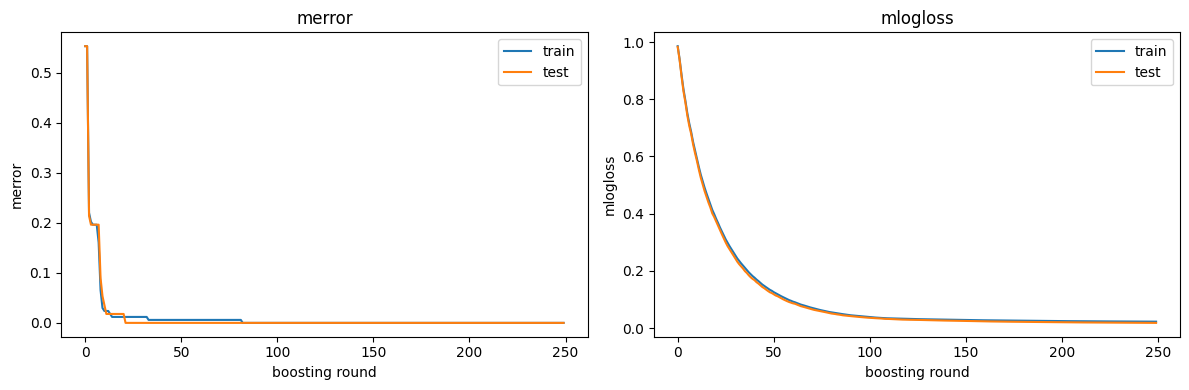

,feature,importance
2,num__flipper_length_mm,0.249052
5,cat__island_Dream,0.212409
4,cat__island_Biscoe,0.154210
6,cat__island_Torgersen,0.151200
0,num__bill_length_mm,0.117421
1,num__bill_depth_mm,0.064909
7,cat__sex_female,0.030561
3,num__body_mass_g,0.013916
8,cat__sex_male,0.006321


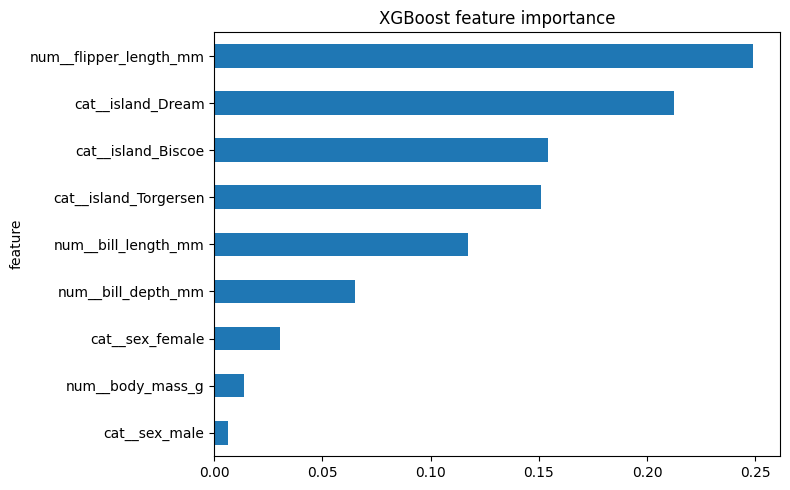

In [8]:
results = xgb_clf.evals_result()
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for metric, axis in zip(["merror", "mlogloss"], axes):
    axis.plot(results["validation_0"][metric], label="train")
    axis.plot(results["validation_1"][metric], label="test")
    axis.set(title=metric, xlabel="boosting round", ylabel=metric)
    axis.legend()
plt.tight_layout()
plt.show()

feature_importance = (
    pd.DataFrame({"feature": transformed_features, "importance": xgb_clf.feature_importances_})
    .sort_values("importance", ascending=False)
)
display(feature_importance)

feature_importance.head(15).sort_values("importance").plot.barh(
    x="feature", y="importance", figsize=(8, 5), legend=False, title="XGBoost feature importance"
)
plt.tight_layout()
plt.show()

## 8. SHAP global and local explanations

Recent SHAP versions typically return multiclass values shaped `(rows, features, classes)`; older versions may return one matrix per class. The helper normalizes both forms.

,Adelie,Chinstrap,Gentoo,overall
num__bill_length_mm,2.135368,1.108399,0.025523,1.089763
num__flipper_length_mm,0.386421,0.040759,1.380246,0.602475
num__bill_depth_mm,0.815856,0.061040,0.707101,0.527999
cat__island_Dream,0.144114,1.335737,0.000000,0.493284
num__body_mass_g,0.016829,0.607250,0.077095,0.233725
cat__island_Biscoe,0.000000,0.142940,0.402612,0.181851
cat__sex_female,0.099935,0.052074,0.000000,0.050670
cat__island_Torgersen,0.029897,0.009006,0.000000,0.012968
cat__sex_male,0.005350,0.000000,0.000000,0.001783


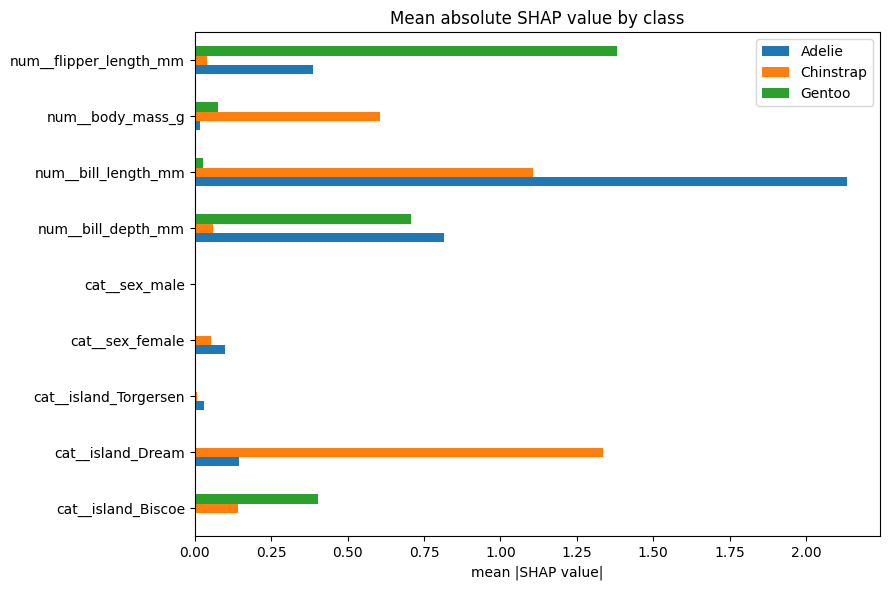

SHAP summary for Adelie


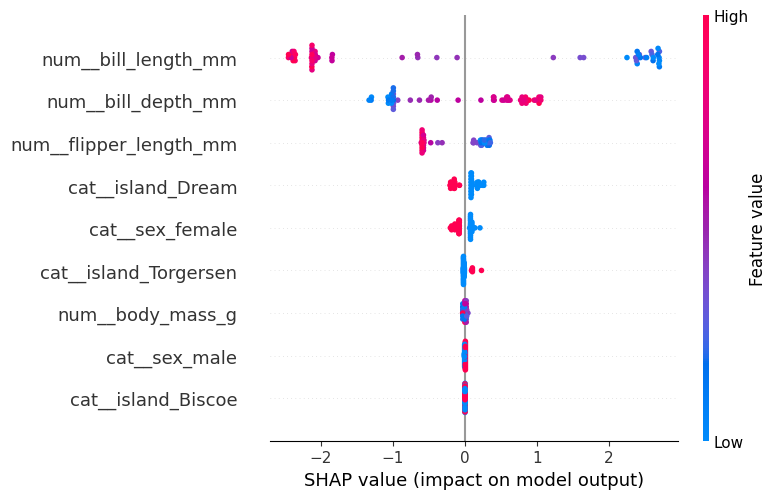

SHAP summary for Chinstrap


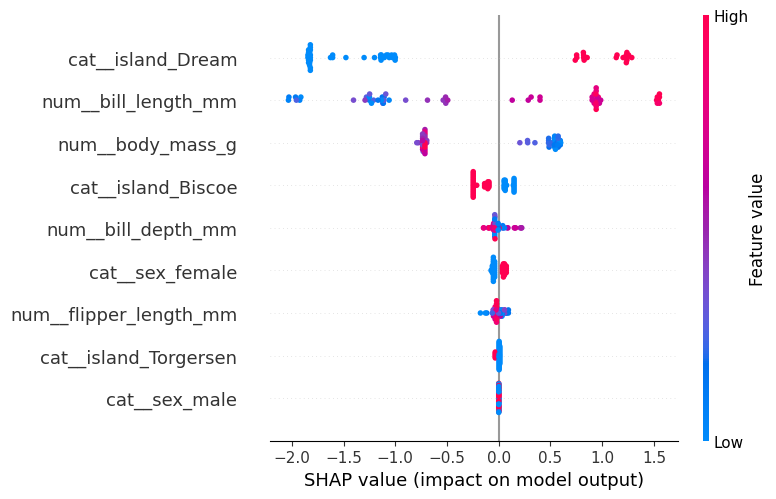

SHAP summary for Gentoo


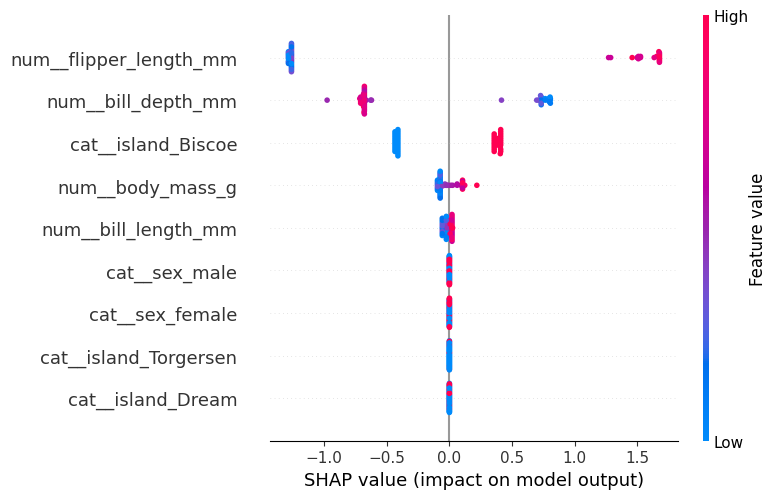

In [9]:
explainer = shap.TreeExplainer(xgb_clf)
raw_shap_values = explainer.shap_values(X_test_df)

def shap_by_class(values, n_classes):
    if isinstance(values, list):
        return values
    values = np.asarray(values)
    if values.ndim == 3 and values.shape[-1] == n_classes:
        return [values[:, :, i] for i in range(n_classes)]
    if values.ndim == 3 and values.shape[0] == n_classes:
        return [values[i] for i in range(n_classes)]
    raise ValueError(f"Unexpected multiclass SHAP shape: {values.shape}")

shap_classes = shap_by_class(raw_shap_values, len(class_names))

mean_abs_shap = pd.DataFrame(
    {name: np.abs(shap_classes[i]).mean(axis=0) for i, name in enumerate(class_names)},
    index=transformed_features,
)
display(mean_abs_shap.assign(overall=mean_abs_shap.mean(axis=1)).sort_values("overall", ascending=False))

mean_abs_shap.head(15).sort_index().plot.barh(figsize=(9, 6))
plt.title("Mean absolute SHAP value by class")
plt.xlabel("mean |SHAP value|")
plt.tight_layout()
plt.show()

for class_index, class_name in enumerate(class_names):
    print(f"SHAP summary for {class_name}")
    shap.summary_plot(
        shap_classes[class_index], X_test_df,
        feature_names=transformed_features, show=True
    )

### Local explanation and reusable reason codes

For each OOT row, the reason code lists the five features with the largest positive contributions toward the model's predicted class.

,Adelie,Chinstrap,Gentoo,predicted_species,actual_species,confidence,reason_code_for_predicted_class
103,0.997452,0.000499,0.002048,Adelie,Adelie,0.997452,num__bill_length_mm;num__bill_depth_mm;num__fl...
146,0.997111,0.001573,0.001315,Adelie,Adelie,0.997111,num__bill_length_mm;num__bill_depth_mm;num__fl...
130,0.996905,0.001970,0.001125,Adelie,Adelie,0.996905,num__bill_length_mm;num__bill_depth_mm;num__fl...
126,0.996781,0.002058,0.001161,Adelie,Adelie,0.996781,num__bill_length_mm;num__bill_depth_mm;num__fl...
107,0.996713,0.001300,0.001987,Adelie,Adelie,0.996713,num__bill_length_mm;num__bill_depth_mm;num__fl...
114,0.996230,0.001561,0.002209,Adelie,Adelie,0.996230,num__bill_length_mm;num__bill_depth_mm;num__fl...
127,0.996108,0.001258,0.002634,Adelie,Adelie,0.996108,num__bill_length_mm;num__bill_depth_mm;num__fl...
325,0.001626,0.996046,0.002328,Chinstrap,Chinstrap,0.996046,num__bill_length_mm;cat__island_Dream;num__bod...
105,0.995885,0.001979,0.002136,Adelie,Adelie,0.995885,num__bill_length_mm;num__bill_depth_mm;num__fl...
100,0.995875,0.001830,0.002295,Adelie,Adelie,0.995875,num__bill_length_mm;num__bill_depth_mm;num__fl...


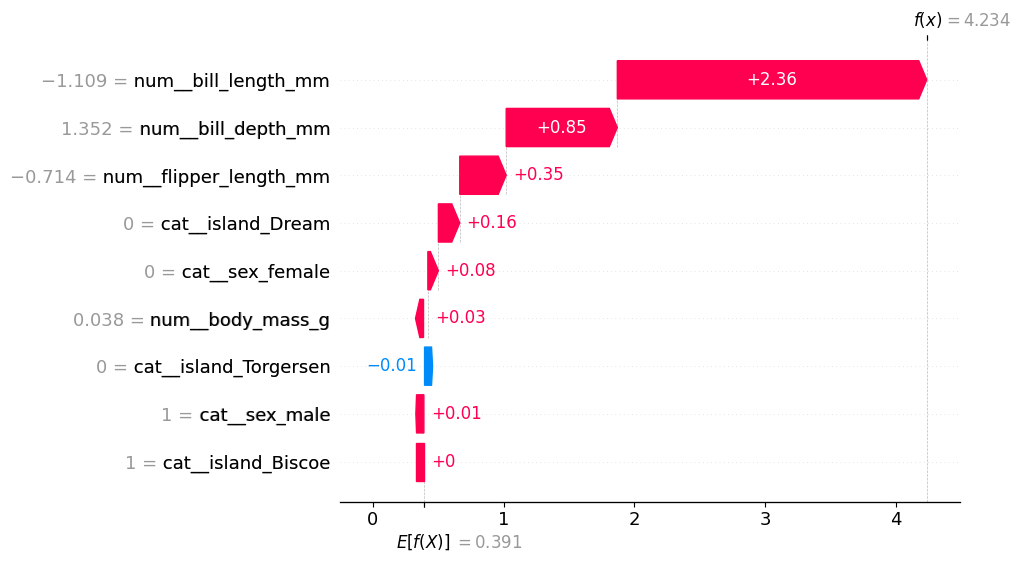

In [10]:
oot_shap_raw = explainer.shap_values(X_oot_df)
oot_shap_classes = shap_by_class(oot_shap_raw, len(class_names))

reason_codes = []
for row_position, predicted_class in enumerate(y_pred_oot_abs):
    contributions = pd.Series(
        oot_shap_classes[predicted_class][row_position],
        index=transformed_features,
    )
    positive = contributions[contributions > 0].sort_values(ascending=False).head(5)
    reason_codes.append(";".join(positive.index))

oot_predictions["reason_code_for_predicted_class"] = reason_codes
display(oot_predictions.sort_values("confidence", ascending=False).head(10))

row_position = int(np.argmax(y_pred_oot.max(axis=1)))
predicted_class = y_pred_oot_abs[row_position]
base_values = np.asarray(explainer.expected_value).reshape(-1)
local_explanation = shap.Explanation(
    values=oot_shap_classes[predicted_class][row_position],
    base_values=base_values[predicted_class],
    data=X_oot_df.iloc[row_position].values,
    feature_names=transformed_features.tolist(),
)
shap.plots.waterfall(local_explanation, max_display=12)

## 9. Save and reload artifacts

Pickle is convenient when Python/library versions are controlled. Never unpickle an untrusted file. For longer-lived or cross-environment deployment, also retain dependency versions and consider XGBoost's native model format.

In [11]:
with open(ARTIFACT_DIR / "preprocessor.pkl", "wb") as file:
    pickle.dump(preprocess_steps, file)
with open(ARTIFACT_DIR / "label_encoder.pkl", "wb") as file:
    pickle.dump(label_encoder, file)
with open(ARTIFACT_DIR / "shap_explainer.pkl", "wb") as file:
    pickle.dump(explainer, file)

xgb_clf.save_model(ARTIFACT_DIR / "penguin_xgb_model.json")
oot_predictions.to_csv(ARTIFACT_DIR / "oot_predictions.csv", index=True)

with open(ARTIFACT_DIR / "preprocessor.pkl", "rb") as file:
    loaded_preprocessor = pickle.load(file)
loaded_model = xgb.XGBClassifier()
loaded_model.load_model(ARTIFACT_DIR / "penguin_xgb_model.json")

reloaded_probabilities = loaded_model.predict_proba(
    pd.DataFrame(
        loaded_preprocessor.transform(X_oot),
        columns=loaded_preprocessor.get_feature_names_out(),
        index=X_oot.index,
    )
)
np.testing.assert_allclose(y_pred_oot, reloaded_probabilities, rtol=1e-6, atol=1e-7)
print("Reload check passed. Artifacts written to:", ARTIFACT_DIR.resolve())

Reload check passed. Artifacts written to: /Users/brad/Documents/ChatGPT/JupyterNotebook Evals/penguin_multiclass_xgboost/data/artifacts


## 10. Suggested experiments

1. Compare the chronological OOT result with repeated stratified cross-validation; explain why they answer different questions.
2. Remove `island` and measure the change. It may be a strong geographic proxy for species, making this a useful leakage/proxy discussion.
3. Tune `max_depth`, `min_child_weight`, `subsample`, `colsample_bytree`, and `learning_rate` using development data only.
4. Compare constant-zero versus median imputation and inspect how their SHAP explanations differ.
5. Add per-class calibration curves and Brier scores; multiclass AUC alone does not test probability calibration.
6. Graduate to Steel Plates Faults, then implement class-weight experiments, gains/lift tables, and threshold-based review queues.

## Methodology improvements over the source notebook

- Separate executable cells and narrative sections instead of one very large cell.
- Use `multi:softprob`, explicit class ordering, and both OvR/OvO macro AUC.
- Fit preprocessing only on training data and preserve a truly untouched OOT slice.
- Include categorical preprocessing rather than silently dropping categorical fields.
- Avoid hard-coded local paths, deprecated pandas aggregation patterns, and fixed SHAP array assumptions.
- Save a native XGBoost JSON model and verify round-trip predictions after reload.